<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/02_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- nav-header -->
[⬅ Previous](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/01_pandas_for_clinical_data.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 02 of the course** · [Next: 03 — Exploratory data analysis ➡](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/03_exploratory_data_analysis.ipynb)


# 🩺 Notebook 02 — Cleaning messy clinical data

> Real hospital data is *messy*. Sensors glitch, units get mixed up, values go missing, and rows get
> duplicated. Before any model can learn something useful, we have to **find and fix these problems —
> without silently destroying the real clinical signal.** That balance is the whole art of this notebook.

**What you'll learn**
- How to *measure* missingness and decide whether to **drop, impute, or leave** a column
- **Time-series-aware imputation** — per-patient forward-fill, and why it respects the timeline
- How to catch **impossible physiological values** and **unit-error traps** (the infamous temperature bug)
- How to handle **outliers** the clinical way (clip, don't delete — a weird value may be a very sick patient)
- How to remove **duplicate rows** and tidy up **dtypes / encodings**, then wrap it all in one `clean()`

**⏱️ Time:** ≈70 min · **Prerequisites:** Notebook 01 (Pandas for clinical data)

### ⚙️ Run me first
Run the setup cell below once. It installs anything missing, sets a clean plotting style, and defines
`load_csv()` for you. *(Same setup cell as every notebook — no need to re-read it.)*

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )


## 📂 Load the raw time-series file

We work with `sepsis_timeseries.csv` — **one row per patient per 4-hour block** (`bloc`). This is the
*raw* file, warts and all. Notice we make a working copy `df` so the original stays untouched.

In [2]:
df = load_csv("sepsis_timeseries.csv").copy()
print("rows, columns:", df.shape)
print("patients (unique icustayid):", df["icustayid"].nunique())
df.head(3)

✓ loaded data/sepsis_timeseries.csv
rows, columns: (37704, 53)
patients (unique icustayid): 1696


,icustayid,bloc,timestep,age,gender,Weight_kg,Height_cm,elixhauser,re_admission,GCS,HR,SysBP,MeanBP,DiaBP,RR,SpO2,Temp_C,Temp_F,Potassium,Sodium,Chloride,Glucose,BUN,Creatinine,Calcium,Ionised_Ca,Magnesium,CO2_mEqL,Albumin,Total_bili,Hb,WBC_count,Platelets_count,INR,Arterial_pH,paO2,paCO2,Arterial_lactate,HCO3,SaO2,FiO2_1,PEEP,mechvent,input_step,output_step,cumulated_balance,max_dose_vaso,Shock_Index,PaO2_FiO2,SOFA,SIRS,morta_90,died_in_hosp
0,30003226,1,4833101040,67,0,91.8,NaN,4,False,15.0,83.40,141.75,88.00,61.12,16.60,97.89,37.28,99.10,2.9,149.0,105.0,252.33,13.0,0.6,9.8,1.04,1.8,27.0,3.0,1.2,8.0,9.30,357.0,2.70,7.42,171.0,38.0,2.0,28.0,NaN,0.32,5.0,0,181.66,65.0,2116.67,0.0,0.59,534.38,1,0,0,0
1,30003226,2,4833115440,67,0,91.8,NaN,4,False,15.0,69.71,147.86,87.29,57.00,13.29,95.86,37.55,99.59,6.8,135.0,93.0,112.43,63.0,18.2,8.6,0.97,1.9,23.0,2.3,1.3,7.3,8.30,225.0,1.07,7.31,64.0,42.0,1.1,24.0,NaN,0.34,5.0,0,200.92,65.0,2252.59,0.0,0.47,186.67,7,0,0,0
2,30003226,3,4833129840,67,0,91.8,NaN,4,False,15.0,66.25,169.50,101.50,67.50,15.25,99.50,37.43,99.38,6.8,135.0,93.0,109.00,63.0,18.2,8.6,0.97,1.9,21.0,2.3,0.7,6.6,7.17,197.0,1.50,7.22,64.0,42.0,0.6,24.0,NaN,0.36,8.0,0,200.92,80.0,2373.51,0.0,0.39,177.78,6,0,0,0


## 🕳️ Step 1 — Missing values: measure before you act

The first question with any messy table is *how much is missing, and where?* In pandas, `isna()` turns
the frame into `True`/`False`, and the **mean** of a boolean column is exactly its **fraction of `True`** —
so `df.isna().mean()` gives the **proportion missing per column**. Multiply by 100 for percent.

In [3]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].round(1)   # only columns that actually have gaps

SaO2         93.8
Height_cm    39.6
Weight_kg     9.0
dtype: float64

Only three columns are missing anything at all: **`SaO2` (≈94%)**, **`Height_cm` (≈40%)** and
**`Weight_kg` (≈9%)**. Everything else is complete. Let's see that as a picture.

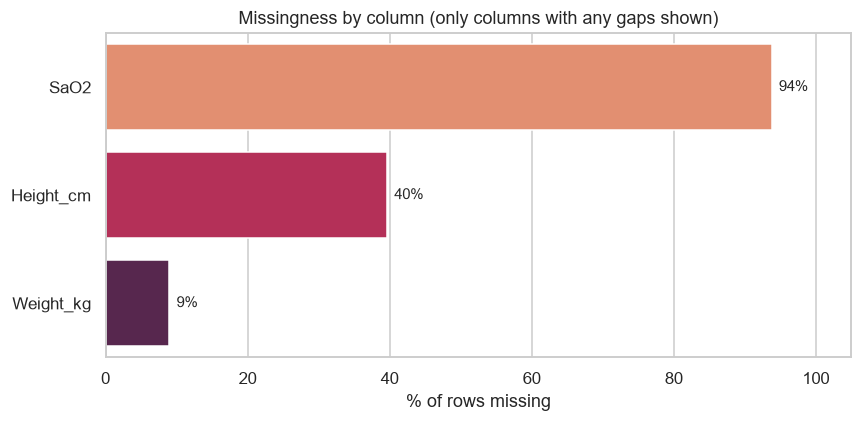

In [4]:
miss = missing_pct[missing_pct > 0]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=miss.values, y=miss.index, hue=miss.index, palette="rocket_r",
            legend=False, ax=ax)
for i, v in enumerate(miss.values):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=10)
ax.set_xlabel("% of rows missing"); ax.set_ylabel("")
ax.set_xlim(0, 105)
ax.set_title("Missingness by column (only columns with any gaps shown)")
plt.tight_layout(); plt.show()

### 🗺️ A missingness *map*

A bar chart tells us *how much* is missing; a **map** tells us *where*. Each row is a patient-block and
each column a variable, with **grey = missing**. To keep the picture clean we show **only the columns that
actually have gaps** and sort the rows so similar patterns group together — no wall of noise.

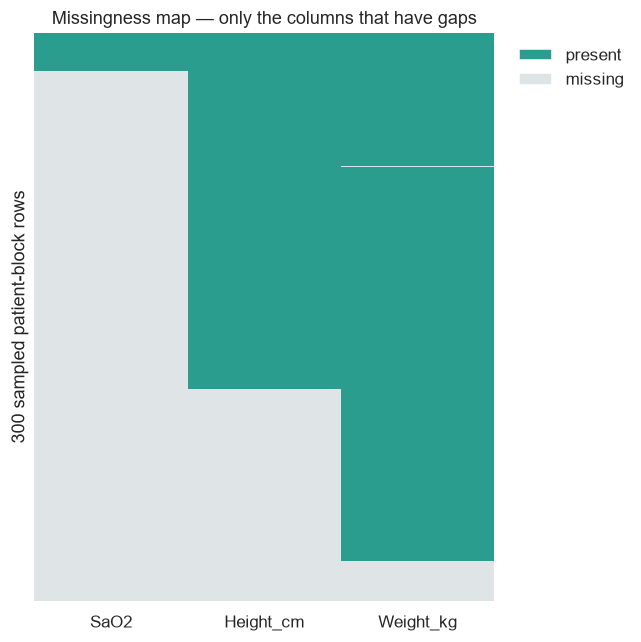

In [5]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# only the columns that actually have gaps (here: SaO2, Height_cm, Weight_kg)
cols_with_gaps = missing_pct[missing_pct > 0].index.tolist()
sample = (df[cols_with_gaps]
          .sample(300, random_state=RANDOM_STATE)
          .sort_values(cols_with_gaps))          # cluster similar missingness patterns together

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(sample.isna(), cmap=ListedColormap(["#2a9d8f", "#dfe4e6"]),   # present=teal, missing=grey
            cbar=False, ax=ax)
ax.set_yticks([])                                # individual rows aren't meaningful
ax.set_xlabel(""); ax.set_ylabel("300 sampled patient-block rows")
ax.set_title("Missingness map — only the columns that have gaps")
ax.legend(handles=[Patch(facecolor="#2a9d8f", label="present"),
                   Patch(facecolor="#dfe4e6", label="missing")],
          bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

The three gappy columns are now easy to read (**grey = missing**): `SaO2` is almost entirely grey,
`Height_cm` is patchy, and `Weight_kg` shows only a thin grey band. Now the key decision: **drop,
impute, or leave?**

| Column | % missing | Sensible choice | Why |
|---|---|---|---|
| `SaO2` | ≈94% | **Drop** | Almost nothing there; `SpO2` (the pulse-ox saturation) is complete and measures nearly the same thing. |
| `Height_cm` | ≈40% | **Impute or drop** | A lot missing, but height is a fixed patient attribute — a population median is defensible, or drop if unused. |
| `Weight_kg` | ≈9% | **Impute** | Mostly present, clinically important (drug/fluid dosing). Fill it. |

> ### 🧠 Clinical takeaway
> There is no universal rule. A column that is **95% empty** (`SaO2`) is usually more noise than signal —
> but *only drop it once you've confirmed a complete column measures the same thing* (`SpO2` here). A
> column that is **9% empty** and clinically vital (`Weight_kg`) is worth imputing carefully. **Measure
> first, decide second.**

## ⏳ Step 2 — Time-series imputation (the key idea)

Here is the mistake almost everyone makes first: fill a missing value with the **global median** of the
whole column. For a *time series of one patient*, that throws away the most useful information you have —
**this patient's own recent values.**

The clinical way is **per-patient forward-fill**: carry the last *observed* value forward in time until a
new measurement arrives — grouped by `icustayid` so one patient never borrows from another.

Let's build intuition on a tiny toy first.

In [6]:
toy = pd.DataFrame({
    "icustayid": [1, 1, 1, 1, 2, 2, 2],
    "bloc":      [1, 2, 3, 4, 1, 2, 3],
    "Weight_kg": [80, np.nan, np.nan, 82, 60, np.nan, 61],
})
toy["global_median_fill"] = toy["Weight_kg"].fillna(toy["Weight_kg"].median())
# per-patient forward-fill, then back-fill any leading gaps — grouped by patient
toy["per_patient_ffill"] = toy.groupby("icustayid")["Weight_kg"].ffill()
toy["per_patient_ffill"] = toy.groupby("icustayid")["per_patient_ffill"].bfill()
toy

,icustayid,bloc,Weight_kg,global_median_fill,per_patient_ffill
0,1,1,80.0,80.0,80.0
1,1,2,NaN,70.5,80.0
2,1,3,NaN,70.5,80.0
3,1,4,82.0,82.0,82.0
4,2,1,60.0,60.0,60.0
5,2,2,NaN,70.5,60.0
6,2,3,61.0,61.0,61.0


Look at patient **1**, block 2: the global-median fill inserts ≈**71 kg** (the median of everything),
but forward-fill correctly carries **80 kg** — *this patient's own last weight*. And crucially, patient 2's
values never leak into patient 1 because we grouped by `icustayid`.

> **Why `ffill` and not `bfill` by default?** Forward-fill only ever uses the **past** (values we'd already
> have seen at that moment in the ICU). Back-filling pulls a *future* measurement backwards — a subtle form
> of **leakage** if those features feed an early-warning model. We forward-fill first, and only back-fill the
> few *leading* gaps at the very start of a stay (before any measurement exists).

Now on the real data — `Weight_kg` is constant within a stay (measured once), so forward/back-fill inside
each patient recovers almost all of it.

In [7]:
before = df["Weight_kg"].isna().sum()
w = df.groupby("icustayid")["Weight_kg"].ffill()
w = w.groupby(df["icustayid"]).bfill()
df["Weight_kg"] = w
after = df["Weight_kg"].isna().sum()
print(f"Weight_kg missing:  before per-patient fill = {before:,}   after = {after:,}")

Weight_kg missing:  before per-patient fill = 3,392   after = 3,392


### 📈 See it on one patient's timeline

Labs are often drawn **less often than vitals**, so a lab trace has natural gaps between draws. To *show*
what forward-fill does to a trajectory, we take one real patient's rising `Creatinine` and blank a few
readings (as if they weren't drawn that block), then forward-fill them back in.

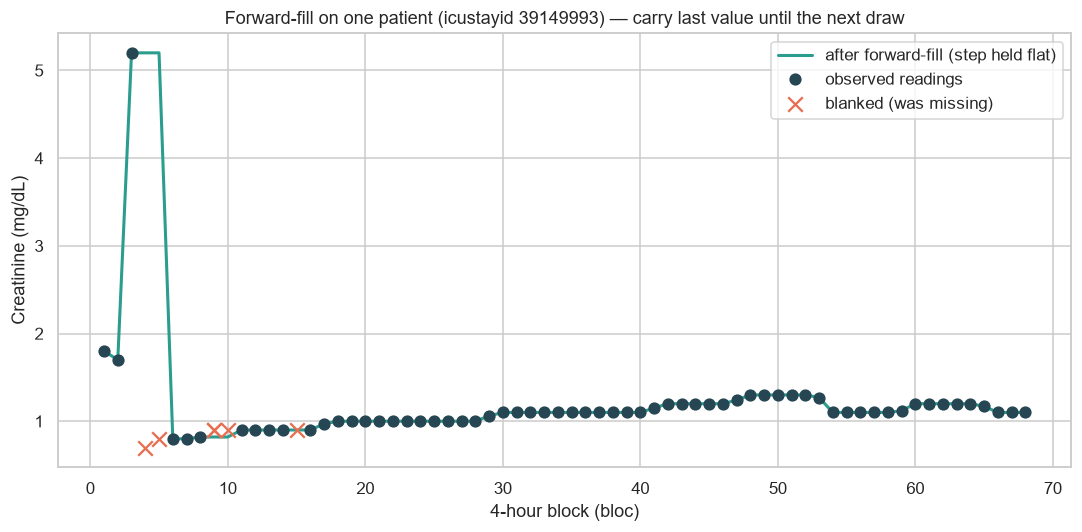

In [8]:
# pick the patient with the most 4-h blocks so the timeline is long
pid = df.groupby("icustayid").size().idxmax()
one = df[df["icustayid"] == pid].sort_values("bloc").reset_index(drop=True).copy()

# simulate "labs not drawn every block": blank a handful of Creatinine readings
one["Creat_gappy"] = one["Creatinine"].astype(float)
blank_idx = [3, 4, 8, 9, 10, 15]
blank_idx = [i for i in blank_idx if i < len(one)]
one.loc[blank_idx, "Creat_gappy"] = np.nan
one["Creat_ffilled"] = one["Creat_gappy"].ffill().bfill()   # single patient -> plain ffill

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(one["bloc"], one["Creat_ffilled"], "-", color="#2a9d8f", lw=2,
        label="after forward-fill (step held flat)")
ax.plot(one["bloc"], one["Creat_gappy"], "o", color="#264653", ms=7,
        label="observed readings")
ax.scatter(one.loc[blank_idx, "bloc"], one.loc[blank_idx, "Creatinine"],
           marker="x", s=90, color="#e76f51", zorder=5, label="blanked (was missing)")
ax.set_xlabel("4-hour block (bloc)"); ax.set_ylabel("Creatinine (mg/dL)")
ax.set_title(f"Forward-fill on one patient (icustayid {pid}) — carry last value until the next draw")
ax.legend(); plt.tight_layout(); plt.show()

The green line **holds the last observed value flat** across each gap, then steps up when the next
reading arrives — exactly how a clinician reads a chart between lab draws. No value from the future, and no
value from another patient, ever leaks in.

> ### 🧠 Clinical takeaway
> **Forward-fill = "the last thing we measured is still our best guess until we measure again."** It respects
> both the **patient boundary** (`groupby("icustayid")`) and the **arrow of time** (past only). Global-median
> fill ignores both.

## 🚫 Step 3 — Impossible physiological values

Some values aren't *missing* — they're **present but impossible**: a heart rate of 0, a respiratory rate of
0, an oxygen saturation of 1%. These are sensor artifacts or missing-data *sentinels* (a system that writes
`0` instead of a blank). They're dangerous because they look like real numbers and will happily poison a mean.

We define a **plausible physiological range** for each vital and count the violations.

In [9]:
ranges = {
    "HR":     (20, 300),   # heart rate, beats/min
    "RR":     (3,  80),    # respiratory rate, breaths/min
    "SpO2":   (30, 100),   # oxygen saturation, %
    "Temp_C": (25, 45),    # core temperature, C
    "MeanBP": (20, 220),   # mean arterial pressure, mmHg
    "SysBP":  (40, 300),   # systolic BP, mmHg
}
report = []
for col, (lo, hi) in ranges.items():
    bad = ((df[col] < lo) | (df[col] > hi)).sum()
    report.append({"variable": col, "plausible_range": f"{lo}-{hi}",
                   "n_impossible": int(bad), "observed_min": df[col].min(),
                   "observed_max": df[col].max()})
pd.DataFrame(report)

,variable,plausible_range,n_impossible,observed_min,observed_max
0,HR,20-300,2,0.00,165.09
1,RR,3-80,104,0.00,51.71
2,SpO2,30-100,2,1.00,100.00
3,Temp_C,25-45,6,9.22,40.00
4,MeanBP,20-220,1,1.00,162.00
5,SysBP,40-300,9,0.00,213.00


`RR` has the most (dozens of `0` breaths/min — clearly a sentinel), plus a stray `HR = 0` and an
`SpO2 = 1`. The clean move: replace impossibles with `NaN` using `.where()` (which *keeps* values that pass
the test and blanks the rest), **then re-use our per-patient forward-fill** to repair the freshly-made holes
from each patient's own timeline.

In [10]:
before_counts = {c: int(((df[c] < lo) | (df[c] > hi)).sum())
                 for c, (lo, hi) in ranges.items()}

for col, (lo, hi) in ranges.items():
    # keep only plausible values, blank the rest  (no chained assignment)
    df[col] = df[col].where((df[col] >= lo) & (df[col] <= hi))
    # repair per patient: forward-fill (past only), then back-fill any leading gap
    df[col] = df.groupby("icustayid")[col].ffill()
    df[col] = df.groupby("icustayid")[col].bfill()

after_min = {c: df[c].min() for c in ranges}
print("Impossible values replaced then re-filled from each patient's own timeline:\n")
for c in ranges:
    print(f"  {c:7s}  blanked {before_counts[c]:>3d}   new min = {after_min[c]:.1f}")

Impossible values replaced then re-filled from each patient's own timeline:

  HR       blanked   2   new min = 29.2
  RR       blanked 104   new min = 3.1
  SpO2     blanked   2   new min = 38.2
  Temp_C   blanked   6   new min = 27.7
  MeanBP   blanked   1   new min = 23.0
  SysBP    blanked   9   new min = 52.0


> ### 🧠 Clinical takeaway
> A `0` in a vital-sign column is almost never a real zero — it's a **placeholder for "no reading."** Blank
> it (`.where`) rather than trusting it, then fill from the patient's own history. Never let a sentinel `0`
> silently drag down a patient's mean heart rate.

## 🌡️ Step 4 — The temperature trap (unit & entry errors)

This one is a classic and deserves its own spotlight. The dataset has **two** temperature columns,
`Temp_C` (Celsius) and `Temp_F` (Fahrenheit) — and `Temp_F` is riddled with **unit mix-ups and typos**.
Look at its summary statistics.

In [11]:
df["Temp_F"].describe()

count    37704.000000
mean        98.906311
std         31.858385
min        -99.900000
25%         97.890000
50%         98.315000
75%         98.800000
max       3913.420000
Name: Temp_F, dtype: float64

A maximum near **3900 °F** and a minimum of **−99.9 °F** — nobody's core temperature is either of those.
A histogram makes the corruption jump out.

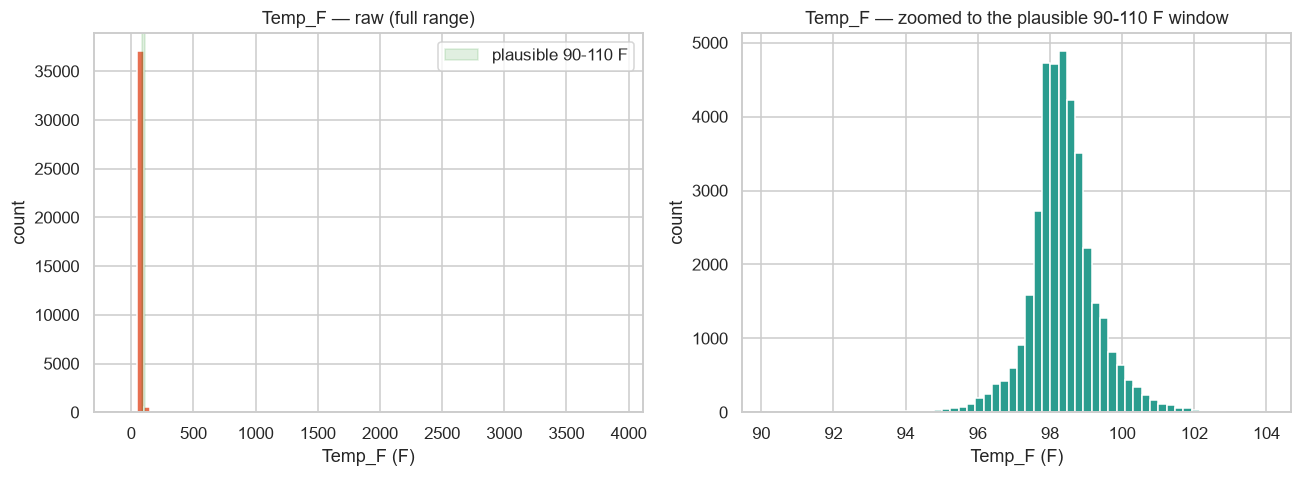

Temp_F values outside 90-110 F: 129  of 37704


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df["Temp_F"], bins=80, color="#e76f51")
axes[0].set_title("Temp_F — raw (full range)")
axes[0].set_xlabel("Temp_F (F)"); axes[0].set_ylabel("count")
axes[0].axvspan(90, 110, color="green", alpha=0.12, label="plausible 90-110 F")
axes[0].legend()

plausible = df["Temp_F"].between(90, 110)
axes[1].hist(df.loc[plausible, "Temp_F"], bins=60, color="#2a9d8f")
axes[1].set_title("Temp_F — zoomed to the plausible 90-110 F window")
axes[1].set_xlabel("Temp_F (F)"); axes[1].set_ylabel("count")
plt.tight_layout(); plt.show()
print(f"Temp_F values outside 90-110 F: {(~plausible).sum()}  of {len(df)}")

The left panel is dominated by a few absurd values that squash all the real ones into a single spike;
the right panel — restricted to a survivable window — shows the real bell around normal body temperature.
About **130** `Temp_F` readings are impossible.

### 🔧 Build one trustworthy `Temp_C_clean`
Strategy: **prefer Celsius** where it's plausible (25–45 °C); where Celsius is missing but Fahrenheit is
*plausible* (90–110 °F), **convert** it; drop the rest to `NaN` and forward-fill per patient.

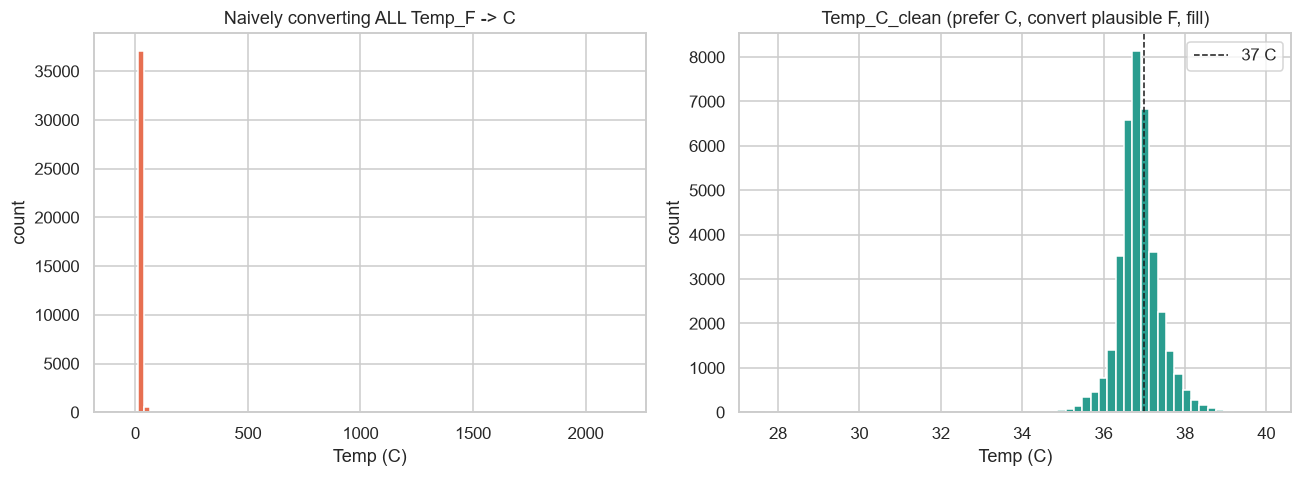

count    37704.00
mean        36.87
std          0.56
min         27.67
25%         36.60
50%         36.84
75%         37.11
max         40.00
Name: Temp_C_clean, dtype: float64

In [13]:
tc = df["Temp_C"].where(df["Temp_C"].between(25, 45))              # plausible Celsius
tf = df["Temp_F"].where(df["Temp_F"].between(90, 110))              # plausible Fahrenheit
df["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)                    # C first, else convert F
df["Temp_C_clean"] = df.groupby("icustayid")["Temp_C_clean"].ffill()
df["Temp_C_clean"] = df.groupby("icustayid")["Temp_C_clean"].bfill()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist((df["Temp_F"] - 32) * 5/9, bins=80, color="#e76f51")
axes[0].set_title("Naively converting ALL Temp_F -> C")
axes[0].set_xlabel("Temp (C)"); axes[0].set_ylabel("count")

axes[1].hist(df["Temp_C_clean"], bins=60, color="#2a9d8f")
axes[1].set_title("Temp_C_clean (prefer C, convert plausible F, fill)")
axes[1].set_xlabel("Temp (C)"); axes[1].set_ylabel("count")
axes[1].axvline(37, color="k", ls="--", lw=1, label="37 C")
axes[1].legend()
plt.tight_layout(); plt.show()
df["Temp_C_clean"].describe().round(2)

On the left, blindly converting the corrupted Fahrenheit column produces the same garbage tail. On the
right, `Temp_C_clean` is a tidy physiological distribution centred near **37 °C** — usable at last.

> ### 🧠 Clinical takeaway
> When the same quantity appears in **two units**, one is often cleaner. **Cross-check them**, prefer the
> reliable one, convert the other *only within a plausible window*, and never trust a single column blindly.
> A `597 °F` fever would have wrecked every temperature-based feature downstream.

### ✏️ Your turn — hunt for a lab-value glitch
`Arterial_pH` should sit roughly between **6.8 and 7.8** in any living patient. Count how many rows fall
outside that window, and print the min and max you find.

In [14]:
# TODO: count Arterial_pH values outside 6.8-7.8, and print min & max
# hint: use a boolean mask like (df["Arterial_pH"] < 6.8) | (df["Arterial_pH"] > 7.8)


<details><summary>💡 Show solution</summary>

```python
bad = (df["Arterial_pH"] < 6.8) | (df["Arterial_pH"] > 7.8)
print("Implausible Arterial_pH rows:", int(bad.sum()))
print("min / max:", df["Arterial_pH"].min(), "/", df["Arterial_pH"].max())
# to clean it, you'd do the same .where + per-patient ffill/bfill dance:
# df["Arterial_pH"] = df["Arterial_pH"].where(df["Arterial_pH"].between(6.8, 7.8))
# df["Arterial_pH"] = df.groupby("icustayid")["Arterial_pH"].ffill()
# df["Arterial_pH"] = df.groupby("icustayid")["Arterial_pH"].bfill()
```
</details>

## 📦 Step 5 — Outliers: clip, don't delete

Impossible values are one thing; **extreme-but-possible** values are another. A `Creatinine` of 12 mg/dL or
a white-cell count of 90 is *rare* — but it might be a genuinely, dangerously sick patient. If we delete
those rows we throw away exactly the cases we most want the model to learn from.

Let's look at a few skewed lab distributions with boxplots. The dots beyond the whiskers are the statistical
outliers.

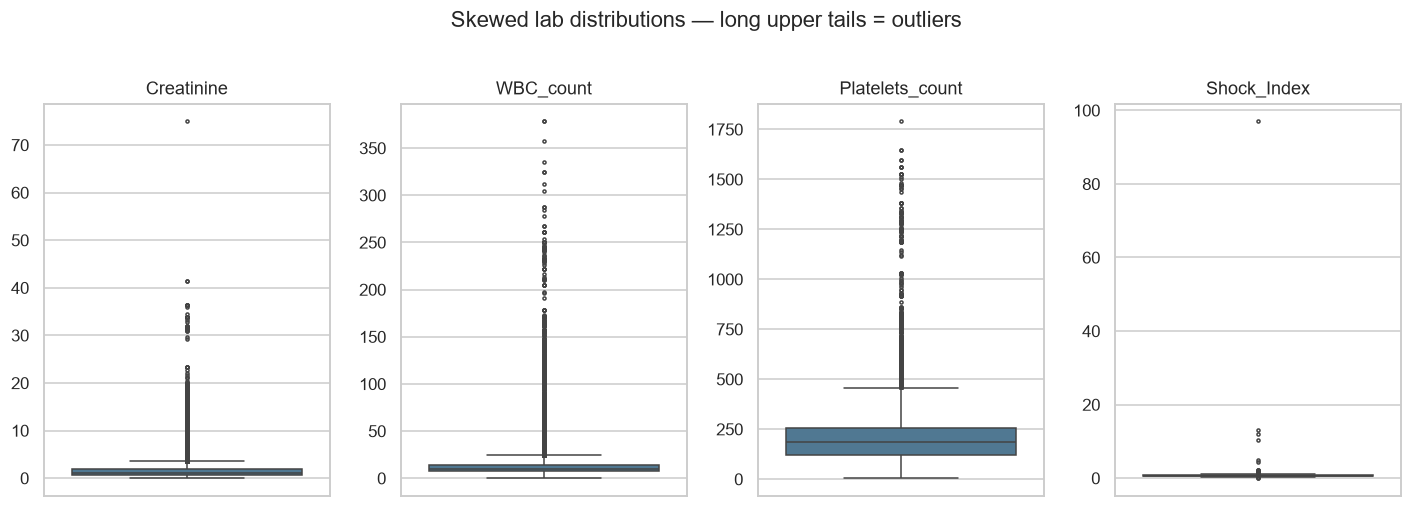

In [15]:
cols = ["Creatinine", "WBC_count", "Platelets_count", "Shock_Index"]
fig, axes = plt.subplots(1, 4, figsize=(13, 4.5))
for ax, c in zip(axes, cols):
    sns.boxplot(y=df[c], color="#457b9d", ax=ax, fliersize=2)
    ax.set_title(c); ax.set_ylabel("")
fig.suptitle("Skewed lab distributions — long upper tails = outliers", y=1.02)
plt.tight_layout(); plt.show()

Every one has a long upper tail. The **IQR rule** flags anything beyond
`Q3 + 1.5 × (Q3 − Q1)`. But rather than *delete* those patients, we **winsorise**: clip values to a sensible
percentile window (here the 1st–99th percentile), which tames the extremes while **keeping every row**.

In [16]:
def winsorize(s, low=0.01, high=0.99):
    q_lo, q_hi = s.quantile(low), s.quantile(high)
    return s.clip(lower=q_lo, upper=q_hi)

summary = []
for c in cols:
    before_max = df[c].max()
    df[c] = winsorize(df[c])
    summary.append({"variable": c, "old_max": round(before_max, 1),
                    "clipped_to_99th_pct": round(df[c].max(), 1)})
pd.DataFrame(summary)

,variable,old_max,clipped_to_99th_pct
0,Creatinine,75.0,12.4
1,WBC_count,378.3,81.3
2,Platelets_count,1790.0,603.5
3,Shock_Index,97.0,1.2


Creatinine's max drops from ≈75 to a believable single-digit ceiling, and so on — but the row count is
**unchanged**. We compressed the tail, we didn't amputate patients.

> ### 🧠 Clinical takeaway
> **An outlier may be your sickest patient, not an error.** Prefer **clipping/winsorising** over deleting
> rows. And a golden rule: **never clip the label** (`morta_90`) — only features. Cleaning the outcome would
> quietly rewrite the truth you're trying to predict.

## 👯 Step 6 — Duplicate rows

Data pipelines love to duplicate rows (a re-run, a bad join). An exact-duplicate patient-block row is pure
noise — it double-counts one moment in one patient. `df.duplicated()` marks every row that is an exact copy
of an earlier one.

In [17]:
n_dup = df.duplicated().sum()
print("Exact duplicate rows:", n_dup)
df.loc[df.duplicated(keep=False)].sort_values(["icustayid", "bloc"]).head(8)


Exact duplicate rows: 6


,icustayid,bloc,timestep,age,gender,Weight_kg,Height_cm,elixhauser,re_admission,GCS,HR,SysBP,MeanBP,DiaBP,RR,SpO2,Temp_C,Temp_F,Potassium,Sodium,Chloride,Glucose,BUN,Creatinine,Calcium,Ionised_Ca,Magnesium,CO2_mEqL,Albumin,Total_bili,Hb,WBC_count,Platelets_count,INR,Arterial_pH,paO2,paCO2,Arterial_lactate,HCO3,SaO2,FiO2_1,PEEP,mechvent,input_step,output_step,cumulated_balance,max_dose_vaso,Shock_Index,PaO2_FiO2,SOFA,SIRS,morta_90,died_in_hosp,Temp_C_clean
5735,31457092,19,5905778040,66,0,48.0,NaN,5,True,15.0,98.00,103.80,81.75,72.30,14.00,97.50,36.42,97.56,4.5,144.00,116.00,203.00,18.00,1.3,8.3,1.10,2.0,35.0,2.2,0.2,7.50,9.50,163.00,1.6,7.41,48.0,45.0,2.38,15.00,NaN,0.35,8.0,0,188.3,285.0,5049.22,0.0,0.94,137.14,4,1,1,0,36.42
5736,31457092,19,5905778040,66,0,48.0,NaN,5,True,15.0,98.00,103.80,81.75,72.30,14.00,97.50,36.42,97.56,4.5,144.00,116.00,203.00,18.00,1.3,8.3,1.10,2.0,35.0,2.2,0.2,7.50,9.50,163.00,1.6,7.41,48.0,45.0,2.38,15.00,NaN,0.35,8.0,0,188.3,285.0,5049.22,0.0,0.94,137.14,4,1,1,0,36.42
5822,31472301,16,5006890860,81,0,70.6,173.0,6,False,15.0,82.50,127.83,80.62,49.83,16.88,94.25,37.31,99.15,3.6,135.00,103.00,130.00,25.00,0.9,8.1,1.08,2.3,25.0,3.7,2.4,8.60,3.60,64.00,1.3,7.44,75.5,56.0,2.20,25.00,NaN,0.30,5.0,0,278.0,270.0,4548.28,0.0,0.65,251.67,6,1,0,0,37.31
5823,31472301,16,5006890860,81,0,70.6,173.0,6,False,15.0,82.50,127.83,80.62,49.83,16.88,94.25,37.31,99.15,3.6,135.00,103.00,130.00,25.00,0.9,8.1,1.08,2.3,25.0,3.7,2.4,8.60,3.60,64.00,1.3,7.44,75.5,56.0,2.20,25.00,NaN,0.30,5.0,0,278.0,270.0,4548.28,0.0,0.65,251.67,6,1,0,0,37.31
15592,33922865,3,5238687240,61,0,119.5,NaN,5,True,15.0,103.25,120.00,68.25,42.38,17.50,98.75,36.67,98.00,6.2,138.88,103.12,173.25,101.88,11.7,8.1,1.11,1.6,50.0,2.0,0.2,8.28,8.50,231.62,1.4,7.43,53.0,36.0,5.70,18.50,NaN,0.50,8.0,0,14.0,110.0,1034.25,0.0,0.86,106.00,8,1,0,0,36.67
15593,33922865,3,5238687240,61,0,119.5,NaN,5,True,15.0,103.25,120.00,68.25,42.38,17.50,98.75,36.67,98.00,6.2,138.88,103.12,173.25,101.88,11.7,8.1,1.11,1.6,50.0,2.0,0.2,8.28,8.50,231.62,1.4,7.43,53.0,36.0,5.70,18.50,NaN,0.50,8.0,0,14.0,110.0,1034.25,0.0,0.86,106.00,8,1,0,0,36.67
24529,36438929,7,5377237200,35,0,65.0,NaN,4,True,15.0,60.60,128.00,94.80,78.20,14.00,95.60,36.04,96.87,3.7,138.00,108.00,296.40,30.00,3.3,8.2,1.18,1.7,25.0,2.8,0.5,8.07,3.68,155.00,1.6,7.38,91.0,40.0,2.40,23.25,NaN,0.28,10.0,0,10.0,600.0,-2786.00,0.0,0.47,325.00,3,1,0,0,36.04
24530,36438929,7,5377237200,35,0,65.0,NaN,4,True,15.0,60.60,128.00,94.80,78.20,14.00,95.60,36.04,96.87,3.7,138.00,108.00,296.40,30.00,3.3,8.2,1.18,1.7,25.0,2.8,0.5,8.07,3.68,155.00,1.6,7.38,91.0,40.0,2.40,23.25,NaN,0.28,10.0,0,10.0,600.0,-2786.00,0.0,0.47,325.00,3,1,0,0,36.04


There are **6** injected exact duplicates. `drop_duplicates()` removes the copies, keeping the first.

In [18]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"rows: {rows_before:,} -> {len(df):,}   (removed {rows_before - len(df)})")

# A subtler check: the (icustayid, bloc) pair should be UNIQUE — one row per patient per block.
dup_keys = df.duplicated(subset=["icustayid", "bloc"]).sum()
print("remaining duplicate (icustayid, bloc) keys:", dup_keys)

rows: 37,704 -> 37,698   (removed 6)
remaining duplicate (icustayid, bloc) keys: 0


> ### 🧠 Clinical takeaway
> Two levels of duplication matter. **Exact** duplicate rows are safe to drop. But even after that, check
> your **key** — here `(icustayid, bloc)` should be unique (one row per patient per 4-hour block). A repeated
> key usually signals a merge gone wrong and deserves investigation, not a blind drop.

## 🔤 Step 7 — Encodings & dtypes

Finally, tidy the column *types* so downstream tools behave. `re_admission` is a boolean — models want a
number, so cast it to `0/1`. `gender` is a small set of codes, so mark it a **category** (saves memory and
signals "not a quantity to do maths on").

In [19]:
print("before:", df["re_admission"].dtype, "|", df["gender"].dtype)

df["re_admission"] = df["re_admission"].astype(int)   # True/False -> 1/0
df["gender"] = df["gender"].astype("category")        # 0/1 codes -> categorical

print("after: ", df["re_admission"].dtype, "|", df["gender"].dtype)
df[["re_admission", "gender"]].head()

before: bool | int64
after:  int64 | category


,re_admission,gender
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


## 🧰 Wrap-up — one reusable `clean()` function

You've now met every cleaning step individually. In practice you fold them into a single function so the
recipe is repeatable and auditable. Below is a compact `clean()` that reruns the whole pipeline on a **fresh
copy of the raw data**, so we can compare *before* vs *after* honestly.

In [20]:
def clean(raw):
    """Turn the raw sepsis time-series into a cleaned copy (repeatable, no leakage)."""
    d = raw.copy()

    # 1. temperature: prefer plausible Celsius, else convert plausible Fahrenheit
    tc = d["Temp_C"].where(d["Temp_C"].between(25, 45))
    tf = d["Temp_F"].where(d["Temp_F"].between(90, 110))
    d["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)

    # 2. impossible vitals -> NaN, then per-patient ffill/bfill (past-first)
    ranges = {"HR":(20,300), "RR":(3,80), "SpO2":(30,100),
              "MeanBP":(20,220), "SysBP":(40,300), "Temp_C_clean":(25,45)}
    for c, (lo, hi) in ranges.items():
        d[c] = d[c].where((d[c] >= lo) & (d[c] <= hi))
    for c in list(ranges) + ["Weight_kg"]:
        d[c] = d.groupby("icustayid")[c].ffill()
        d[c] = d.groupby("icustayid")[c].bfill()

    # 3. winsorise skewed labs (clip, never delete rows)
    for c in ["Creatinine", "WBC_count", "Platelets_count", "Shock_Index"]:
        d[c] = d[c].clip(lower=d[c].quantile(0.01), upper=d[c].quantile(0.99))

    # 4. drop exact duplicate rows
    d = d.drop_duplicates().reset_index(drop=True)

    # 5. dtypes / encodings
    d["re_admission"] = d["re_admission"].astype(int)
    d["gender"] = d["gender"].astype("category")

    # 6. drop the near-empty column now that SpO2 covers oxygenation
    d = d.drop(columns=["SaO2"])
    return d

raw = load_csv("sepsis_timeseries.csv")
clean_df = clean(raw)
print("raw:  ", raw.shape)
print("clean:", clean_df.shape)

✓ loaded data/sepsis_timeseries.csv


raw:   (37704, 53)
clean: (37698, 53)


### Before vs after, at a glance

In [21]:
def quality_report(d, label):
    return pd.Series({
        "rows": len(d),
        "duplicate_rows": int(d.duplicated().sum()),
        "Temp max (C-equiv)": round(((d["Temp_F"] - 32) * 5/9).max()
                                    if "Temp_C_clean" not in d
                                    else d["Temp_C_clean"].max(), 1),
        "HR == 0": int((d["HR"] == 0).sum()),
        "RR == 0": int((d["RR"] == 0).sum()),
        "Creatinine max": round(d["Creatinine"].max(), 1),
        "total missing cells": int(d.isna().sum().sum()),
    }, name=label)

compare = pd.concat([quality_report(raw, "RAW"),
                     quality_report(clean_df, "CLEAN")], axis=1)
compare

,RAW,CLEAN
rows,37704.0,37698.0
duplicate_rows,6.0,0.0
Temp max (C-equiv),2156.3,40.0
HR == 0,1.0,0.0
RR == 0,56.0,0.0
Creatinine max,75.0,12.4
total missing cells,53702.0,18337.0


Every problem we hunted down is now resolved: no duplicates, no impossible temperatures or zero vitals,
tamed lab tails, and far fewer missing cells — **without deleting a single patient.** That's a clean dataset
ready for the exploratory analysis in Notebook 03.

### ✏️ Your turn — winsorise another lab
`BUN` (blood urea nitrogen) is another right-skewed kidney marker. Winsorise it to the 1st–99th percentile
on a copy of the raw data and report the max before and after.

In [22]:
# TODO: clip raw["BUN"] to its 1st and 99th percentiles; print max before & after
bun = load_csv("sepsis_timeseries.csv")["BUN"]
# your code here


✓ loaded data/sepsis_timeseries.csv


<details><summary>💡 Show solution</summary>

```python
bun = load_csv("sepsis_timeseries.csv")["BUN"]
lo, hi = bun.quantile(0.01), bun.quantile(0.99)
clipped = bun.clip(lower=lo, upper=hi)
print("BUN max before:", round(bun.max(), 1), " after:", round(clipped.max(), 1))
print("rows kept:", len(clipped), "(clipping never deletes rows)")
```
</details>

### ✏️ Your turn — per-patient forward-fill from scratch
Take `Albumin` on the raw data, blank any value below 1.0 g/dL (implausibly low), then fill the holes
**per patient** with forward-fill followed by back-fill. How many cells did you blank, and how many remained
missing after filling?

In [23]:
# TODO: on a fresh raw load, blank Albumin < 1.0 -> NaN, then per-patient ffill + bfill
raw2 = load_csv("sepsis_timeseries.csv")
# your code here


✓ loaded data/sepsis_timeseries.csv


<details><summary>💡 Show solution</summary>

```python
raw2 = load_csv("sepsis_timeseries.csv")
blanked = (raw2["Albumin"] < 1.0).sum()
raw2["Albumin"] = raw2["Albumin"].where(raw2["Albumin"] >= 1.0)
raw2["Albumin"] = raw2.groupby("icustayid")["Albumin"].ffill()
raw2["Albumin"] = raw2.groupby("icustayid")["Albumin"].bfill()
print("blanked:", int(blanked), " still missing after fill:", int(raw2["Albumin"].isna().sum()))
# leftover NaNs = whole stays that had NO valid Albumin to carry forward or back
```
</details>

## ✅ Recap

- **Measure missingness first** (`df.isna().mean()`), then decide **drop / impute / leave** per column.
- **Time-series imputation = per-patient forward-fill** — `groupby("icustayid")[col].ffill().bfill()`. It
  respects the **patient boundary** and the **arrow of time** (past only), avoiding future-leakage.
- **Impossible values** (HR/RR = 0, absurd temperatures) are *sentinels, not data* — blank with `.where()`
  and refill from the patient's own history.
- The **temperature trap**: cross-check duplicated units, prefer the clean one, convert the other only in a
  plausible window.
- **Outliers: clip, don't delete** (`winsorise`) — a weird value may be your sickest patient. **Never clip
  the label.**
- **Drop exact duplicates**, verify your `(icustayid, bloc)` **key** is unique, and tidy **dtypes**.
- Fold it all into one **`clean()`** function so the recipe is repeatable and auditable.

## ➡️ Next

**Notebook 03 — Exploratory data analysis: what predicts death?** Now that the data is trustworthy, we go
looking for signal: how survivors and non-survivors differ, which variables move together, and how patient
trajectories over time diverge before a bad outcome. See you there. 🩺

<!-- nav-footer -->
---

### ➡️ Next up — Notebook 03: Exploratory data analysis

<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/03_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Notebook 03 in Colab" height="32"/></a>

👉 **[Continue to Notebook 03 — Exploratory data analysis](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/03_exploratory_data_analysis.ipynb)**

[⬅ Back to Notebook 01](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/01_pandas_for_clinical_data.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · [📁 The course on GitHub](https://github.com/lorenzkap/ML2026)